In [1]:
import pandas as pd
import numpy as np
from scipy.interpolate import RegularGridInterpolator
import os
from pathlib import Path
root = str(Path.cwd().parent.parent)
import sys
sys.path.append(f'{root}/src')
import constants as cs

import netCDF4 as nc
import xarray as xr
from pygmt.params import Box, Position

import pyproj
# proj_path = pyproj.datadir.get_data_dir()

# os.environ["PROJ_LIB"] = proj_path
# os.environ["PROJ_DATA"] = proj_path

# pyproj.network.set_network_enabled(True)  # ensures CRS lookup works

import geopandas as gpd
import pygmt

In [2]:
# ### creating scaffold of figure first
# fig = pygmt.Figure()
# w  = 10
# h  = 3

# ### Bottom row, not as tall
# with fig.subplot(nrows=1, ncols=1, figsize=(f"{w}c", f"{h}c"), autolabel="b)"):
#     fig.basemap(
#         region=[0, 5, 0, 5], projection="X?", frame=["af", "WSne"], panel=[0, 0]
#     )
    
# ### Move plot origin by 1 cm above the height of the entire figure
# fig.shift_origin(yshift="h+1c")
# ### Top row, rectangle
# with fig.subplot(nrows=1, ncols=1, figsize=(f"{w}c", f"{w}c"), autolabel="a)"):
#     fig.basemap(
#         region=[0, 10, 0, 10], projection="X?", frame=["af", "WSne"], panel=[0, 0]
#     )

# fig.show()

In [3]:
### read in ice history
iceHist = xr.open_dataset(f'{root}/inputs/iceHistories/iceHistory-CISLGM_icepc_022226_highres_256.nc')
### need to solvefor ind
grid_ice = iceHist["ice_thickness"].sel(time=17)

In [4]:
### read in Gebco
grid_GEBCO = xr.open_dataset(f'{root}/inputs/GEBCO_03_Nov_2022_a5af2d998654/gebco_2022_n67.0_s43.0_w-179.0_e-117.0.nc')
grid_GEBCO = grid_GEBCO['elevation']

# grid_GEBCO = 
# nc.Dataset('inputs/GEBCO_03_Nov_2022_a5af2d998654/gebco_2022_n67.0_s43.0_w-179.0_e-117.0.nc')
# GEBCO_lat = GEBCO['lat'][:]
# GEBCO_lon = GEBCO['lon'][:]
# GEBCO_elev = GEBCO['elevation'][:,:]

# GEBCO_LON,GEBCO_LAT = np.meshgrid(GEBCO_lon,GEBCO_lat)

In [5]:
### read in rsl of ice history
rsl = nc.Dataset(f'{root}/inputs/rsl/rsl-CISLGM_icepc_022226_highres-prem.l50.ump2.lm3_lvz_200km.yt.nc')

In [6]:
# grid_gebco = pygmt.xyz2grd(
#     x = GEBCO_LON.flatten(),
#     y = GEBCO_LAT.flatten(),
#     z = GEBCO_elev.flatten(),
#     region = [float(np.min(GEBCO_lon)), float(np.max(GEBCO_lon)), float(np.min(GEBCO_lat)), float(np.max(GEBCO_lat))],
#     # spacing = (f'{GEBCO_lon.shape[0]}+n',f'{GEBCO_lat.shape[0]}+n')
#     spacing = (0.00416667,0.00416667)
# )

In [7]:
# vols_out = np.loadtxt('outputs/iceVolTime.txt')
cord_gmsl = np.loadtxt(f'{root}/outputs/cordilleranGMSL.txt')

In [8]:
### read in flowlines
jdf = pd.read_excel(f'{root}/inputs/flowlines/jdf_update.xlsx')
sv = pd.read_excel(f'{root}/inputs/flowlines/sv.xlsx')
ysv = pd.read_excel(f'{root}/inputs/flowlines/ysv_update.xlsx')
flowlines = [jdf, sv, ysv]

In [9]:
clrs = [cs.clr_s, cs.clr_c, cs.clr_n]

In [11]:
### reading in shapefiles for territories
nt = gpd.read_file(f'{root}/inputs/territoryShapefiles/AL_TA_NT_SHP_GMD_fra/AL_TA_NT_2_164_CONFIRME_fra.shp')
ab = gpd.read_file(f'{root}/inputs/territoryShapefiles/AL_TA_AB_SHP_GMD_fra/AL_TA_AB_2_164_CONFIRME_fra.shp')
yt = gpd.read_file(f'{root}/inputs/territoryShapefiles/AL_TA_YT_SHP_GMD_fra/AL_TA_YT_2_164_CONFIRME_fra.shp')
bc = gpd.read_file(f'{root}/inputs/territoryShapefiles/AL_TA_BC_SHP_GMD_fra/AL_TA_BC_2_164_CONFIRME_fra.shp')
al = gpd.read_file(f'{root}/inputs/territoryShapefiles/Alaska_aiannh.shp')

In [12]:
shapes = [nt, ab, yt, bc, al]

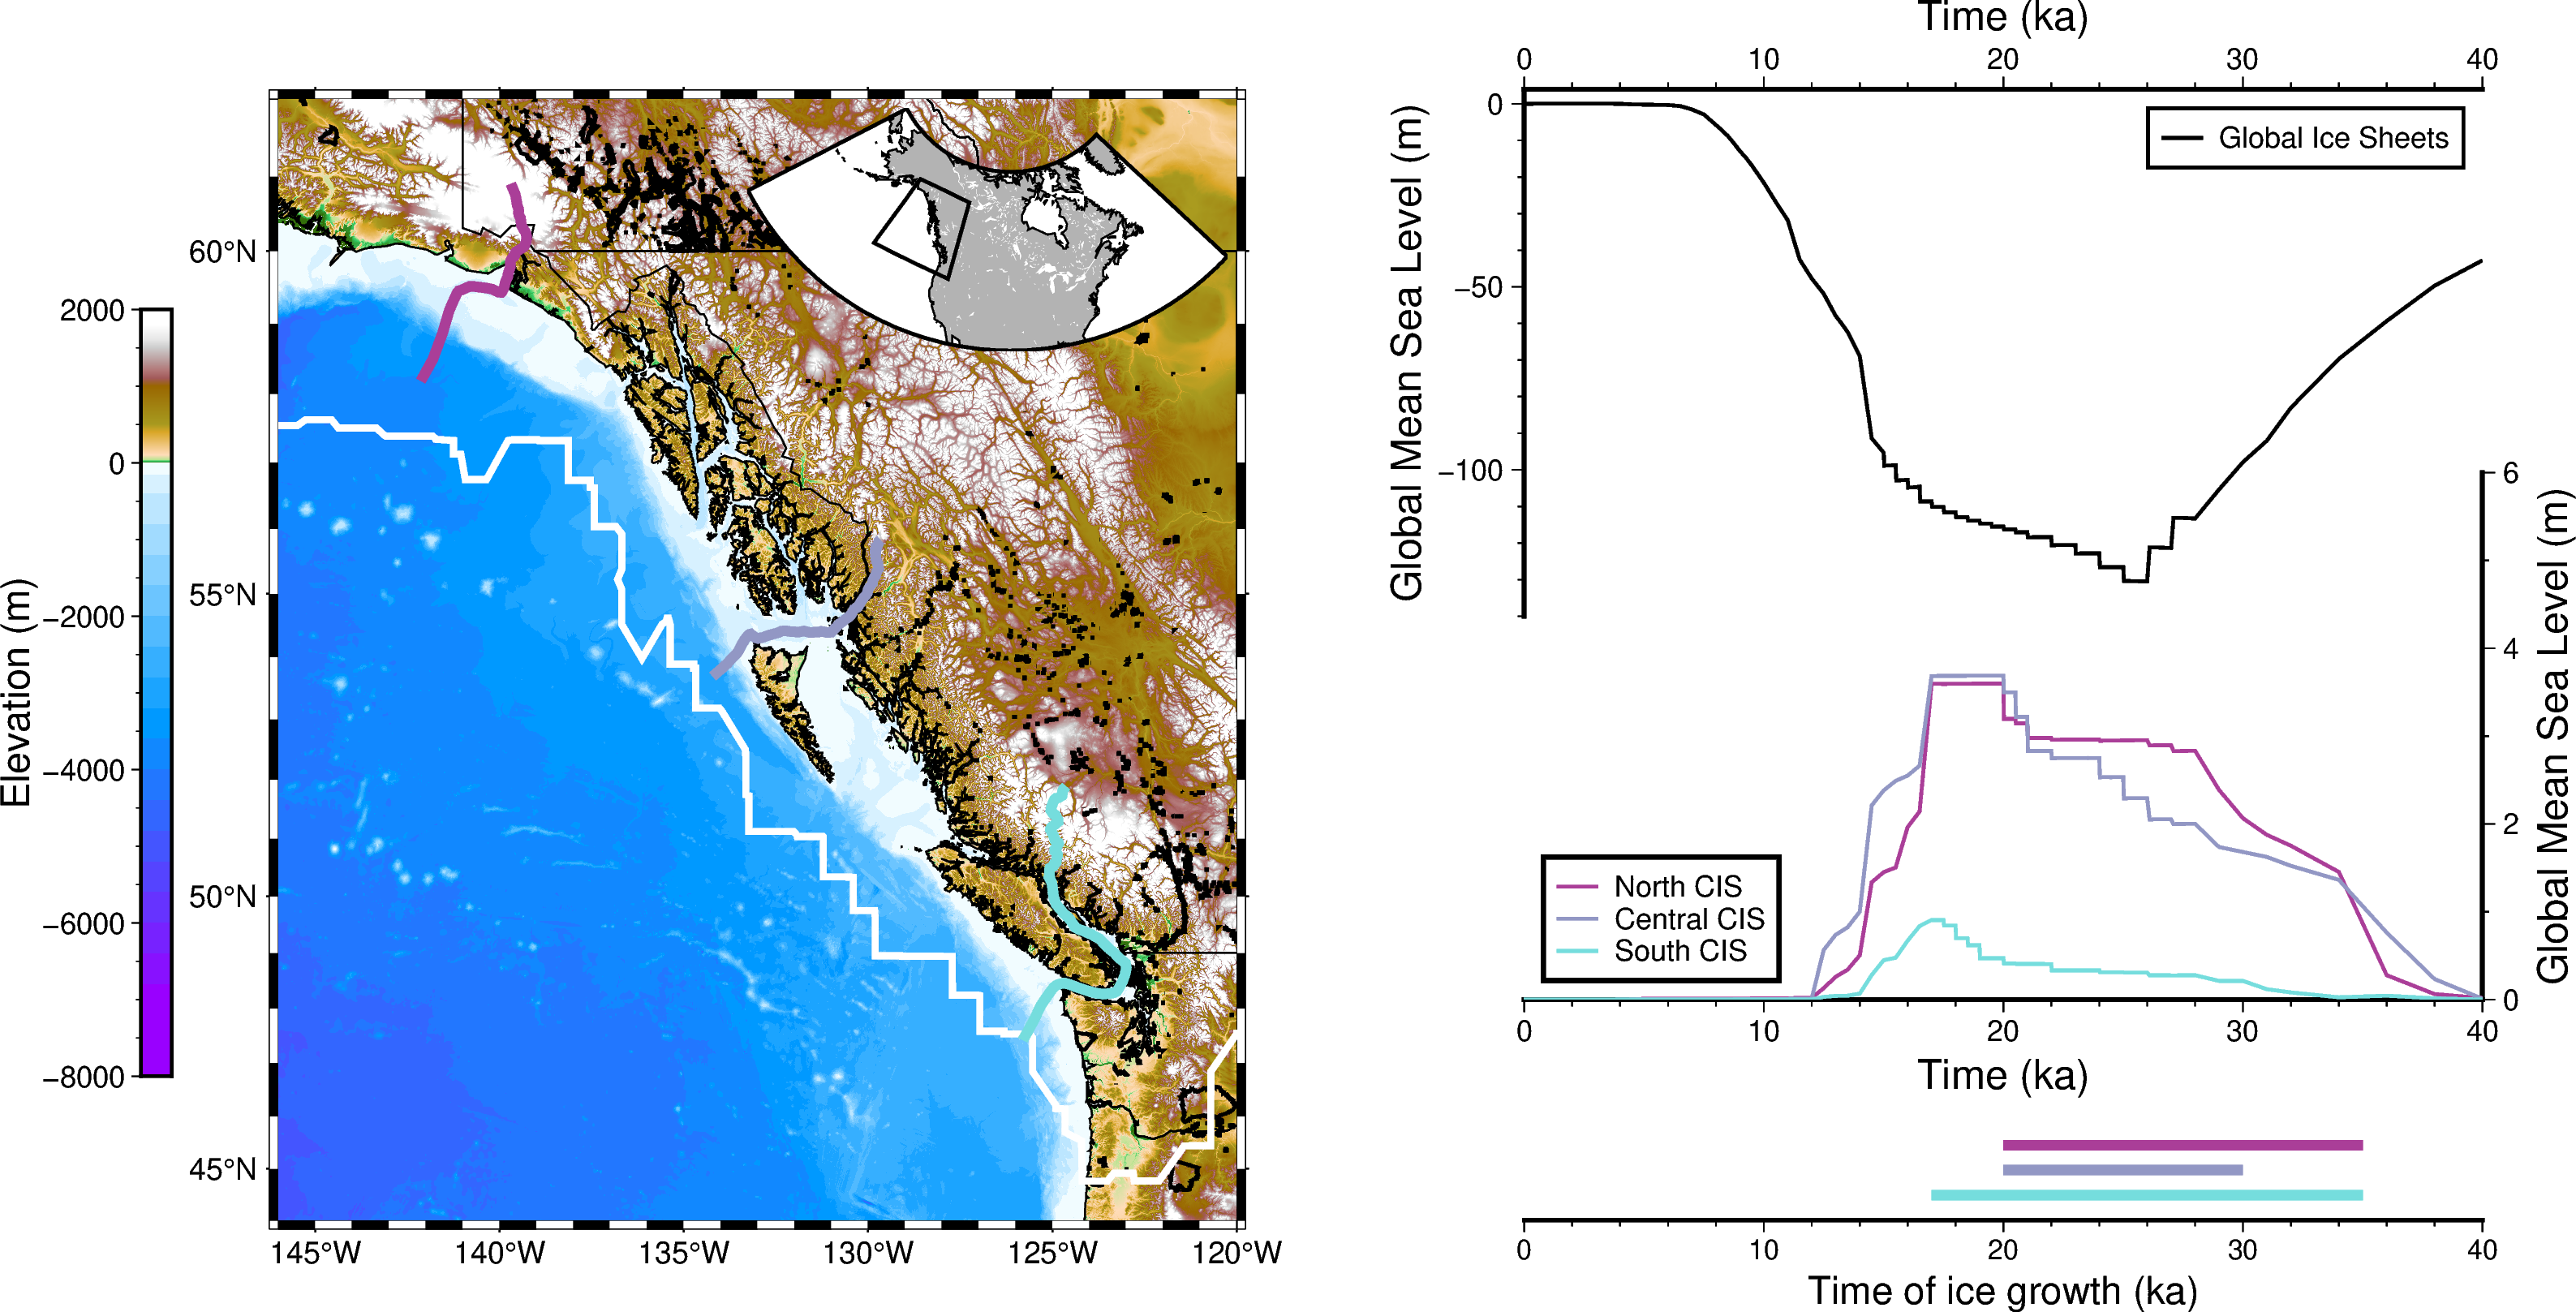

In [19]:
### creating figure
fig = pygmt.Figure()
### set up for figure
w  = 10
h  = 5
### creating region and extents
xmin = 360 - 146.
xmax = 360 - 120.
ymin = 44.
ymax = 62.
region = [xmin,xmax,ymin,ymax]
projection = f'M0/0/{w}c'
###

####################
### left panel, map of ice extent
###################
with fig.subplot(nrows=1, ncols=1, figsize=(f"{w}c", f"{w}c")):
    ### creating basemap
    fig.basemap(region = region,
         projection = projection,
               frame = ['afg'])

    ### plotting topography
    pygmt.makecpt(cmap="gmt/globe+h", series=[-8000, 2000])
    fig.grdimage(grid=grid_GEBCO,
                  region = region,
                  projection = projection,
                 )
    with pygmt.config(FONT_ANNOT_PRIMARY="12p", FONT_LABEL="16p"):
        fig.colorbar(frame = ['a2000f500', "x+lElevation (m)"], position=Position("LM", 'outside', offset = (-2,0.5), anchor = 'CM'), 
                     orientation = 'vertical', 
                     move_text = ['annotations', 'label', 'unit'])

    ### boundaries and shorelines
    fig.coast(shorelines="1/0.5p,black", borders = 'a/0.5p,black', region = region, projection = projection)

    for shape in shapes:
        fig.plot(data=shape, pen='1p,black',projection = projection)

    ### ice extent and flowlines
    x2, y2 = np.meshgrid(grid_ice['lon'].values, grid_ice['lat'].values)
    dum = np.copy(np.ravel(grid_ice.values))
    dum[np.isnan(dum)] = 0
    fig.contour(region = region,
                projection = projection,
                x = np.ravel(x2),
                y = np.ravel(y2),
                z = dum,
                levels = [1],
                pen = '2p,white',
               )

    for n, flow in enumerate(flowlines):
        fig.plot(x = flow['Lon'], y = flow['Lat'], pen = f'{cs.lw}p,{clrs[n]}', projection = projection, region=region)

        
    ### Creating inset
    xmin_inset, xmax_inset = -180, -40
    ymin_inset, ymax_inset = 30, 70
    region_inset = [xmin_inset, xmax_inset, ymin_inset, ymax_inset]
    with fig.inset(
        position=Position("TR", offset=0.1),
        # box=Box(fill="white", pen="1p"),
        region=region_inset,
        projection=f"L{(-100)}/35/{ymin_inset}/{ymax_inset}/5c",
    ):
        with pygmt.config(
            MAP_FRAME_TYPE="plain",
            MAP_FRAME_PEN="1p,black",
            # MAP_TICK_PEN="0p",
            # FONT_ANNOT_PRIMARY="0p",
        ):
            ### adding coastlinies
            fig.coast(shorelines="1/0.5p,black", region = region_inset, land="gray70", water="white",frame = ['wnse'])

        ### plotting rectangle over area
        rectangle = [[region[0], region[2], region[1], region[3]]]
        fig.plot(data=rectangle, style="r+s", pen="1p,black")
        


fig.shift_origin(xshift=f"w+{3}c")
####################
### bottom right row, times of ice growth
###################

with fig.subplot(nrows=1, ncols=1, figsize=(f"{w}c", f"{1.3}c")):
    fig.basemap(
            region=[0, 40, 1.6e15, 2.1e15], 
            projection="X?", frame=['S', 'x+lTime of ice growth (ka)'], 
            panel=[0, 0],
            )
    lw = 3
    ### plotting lines of times of ice sheet growth
    fig.plot(x = [35,20], y = [1.9e15,1.9e15], pen = f'{cs.lw}p,{cs.clr_n}')
    fig.plot(x = [30,20], y = [1.8e15,1.8e15], pen = f'{cs.lw}p,{cs.clr_c}')
    fig.plot(x = [35,17], y = [1.7e15,1.7e15], pen = f'{cs.lw}p,{cs.clr_s}')


fig.shift_origin(yshift=f"h+1c")
####################
### center right row, ice growth in gmsl equilivent
###################
with fig.subplot(nrows=1, ncols=1, figsize=(f"{w}c", f"{5.5}c")):
    fig.basemap(
        region=[0, 40, 0, 6], 
        projection="X?", frame=["af", "ES", "xaf+lTime (ka)", "yaf+lGlobal Mean Sea Level (m)" ], 
        panel=[0, 0],
        
    )

    fig.plot(x = cord_gmsl[:,0], y=cord_gmsl[:,1]*-1, label = "North CIS", pen = f'1p,{cs.clr_n}')
    fig.plot(x = cord_gmsl[:,0], y=cord_gmsl[:,2]*-1, label = "Central CIS", pen = f'1p,{cs.clr_c}')
    fig.plot(x = cord_gmsl[:,0], y=cord_gmsl[:,3]*-1, label = "South CIS", pen = f'1p,{cs.clr_s}')

    fig.legend(position=Position("BL",offset = 0.2),box=True, scale = 1)
    # fig.legend(position="BL+o0.2c/0.2c+w4c",box = True)

####################
### top right row, global mean sea level
###################
fig.shift_origin(yshift = 'h-1.5c')

with fig.subplot(nrows=1, ncols=1, figsize=(f"{w}c", f"{5.5}c")):
    fig.basemap(
        region=[0, 40, -140, 4], 
        projection="X?", frame=["af", "NW", "xaf+lTime (ka)", "yaf+lGlobal Mean Sea Level (m)"], 
        panel=[0, 0],
        )
    fig.plot(x = rsl['t'][:], y = rsl['gmsl'][:], label = 'Global Ice Sheets', pen = '1p,black')
    # # text for legend
    # fig.plot(
    #     x=[None],
    #     y=[None],
    #     label="Sea Level"
    # )


fig.show()
# fig.savefig(f'{root}/figures/f01_transectMap.pdf')